In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch 

In [2]:
from anomaly_detection.utils.load_sam_data import load_dataset
from anomaly_detection.utils.preprocess import drop_empty_histograms
from anomaly_detection.utils.preprocess import minmax_scale_per_sample

dataset = load_dataset("FJ")
full_dataset = np.array(dataset)
full_dataset = minmax_scale_per_sample(full_dataset)

dataset_no_outs = drop_empty_histograms(full_dataset)

Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\FJ\FI01X1\FI01X1_ch
Dropped indexes [8, 15, 188, 214, 263, 268, 533, 546]


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(dataset_no_outs, shuffle=True, train_size=0.8, random_state=42)

In [4]:
full_dataset = torch.from_numpy(full_dataset)
full_dataset = full_dataset.to(torch.float32)

In [5]:
from anomaly_detection.config.paths import CHECKPOINT_DIR
from anomaly_detection.models.ano_gan_v1 import Generator, Discriminator, Encoder 

checkpoint = torch.load(f"{CHECKPOINT_DIR}/f_anogan_v1.pth", map_location="cpu")

generator = Generator()
discriminator = Discriminator()
encoder = Encoder()

generator.load_state_dict(checkpoint["generator"])
discriminator.load_state_dict(checkpoint["discriminator"])
encoder.load_state_dict(checkpoint["encoder"])

generator.eval()
discriminator.eval()
encoder.eval()

Encoder(
  (conv1): Conv1d(1, 1, kernel_size=(8,), stride=(1,), padding=(1,))
  (conv2): Conv1d(1, 1, kernel_size=(6,), stride=(1,), padding=(1,))
  (conv3): Conv1d(1, 1, kernel_size=(3,), stride=(2,), padding=(1,))
  (conv4): Conv1d(1, 1, kernel_size=(3,), stride=(2,), padding=(1,))
)

In [6]:
g_trainable_params = sum(p.numel() for p in generator.parameters() if p.requires_grad)
d_trainable_params = sum(p.numel() for p in discriminator.parameters() if p.requires_grad)
e_trainable_params = sum(p.numel() for p in encoder.parameters() if p.requires_grad)

print("Generator consists of", g_trainable_params, "trainable parameters.")
print("Disc consists of", d_trainable_params, "trainable parameters.")
print("Encoder consists of", e_trainable_params, "trainable parameters.")
# TODO: idk co je tohle

Generator consists of 5018452 trainable parameters.
Disc consists of 128520 trainable parameters.
Encoder consists of 24 trainable parameters.


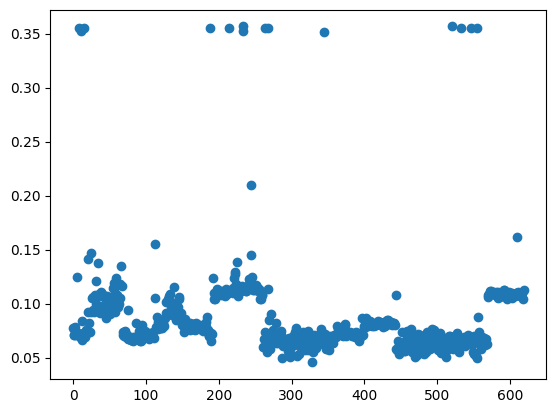

In [12]:
from anomaly_detection.models.ano_gan_v1 import anomaly_score
scores = []
for pt in full_dataset:
    pt = pt.reshape(1,1,96)
    scores.append(anomaly_score(pt, generator, discriminator, encoder).detach().numpy())

plt.scatter(range(len(full_dataset)), scores)

In [14]:
import pandas as pd 
from anomaly_detection.config.paths import DATA_DIR
import os

eval_df = pd.read_parquet(os.path.join(DATA_DIR, 'eval_data', 'eval_dataset.parquet'))

In [17]:
eval_score = []
for pt in eval_df['histogram']:
    pt = torch.tensor(pt).to(torch.float32).reshape(1, 1, 96)
    eval_score.append(anomaly_score(pt, generator, discriminator, encoder).detach().numpy())

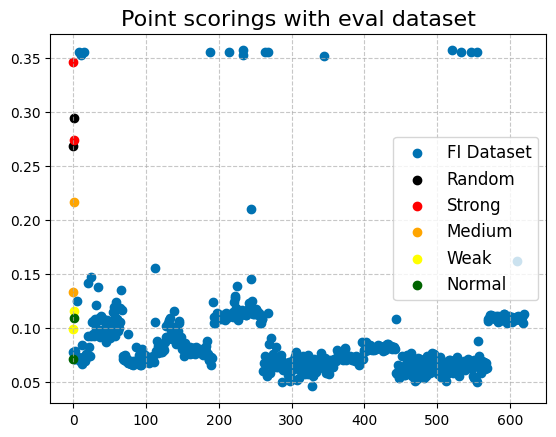

In [18]:
from anomaly_detection.utils.plotting_styles import apply_global_style
apply_global_style()
plt.title("Point scorings with eval dataset")
plt.scatter(range(len(scores)), scores, label='FI Dataset')
plt.scatter(range(len(eval_score[:2])), eval_score[:2], color='black', label='Random')
plt.scatter(range(len(eval_score[2:4])), eval_score[2:4], color='red', label='Strong')
plt.scatter(range(len(eval_score[4:6])), eval_score[4:6], color='orange', label='Medium')
plt.scatter(range(len(eval_score[6:8])), eval_score[6:8], color='yellow', label='Weak')
plt.scatter(range(len(eval_score[8:])), eval_score[8:], color='darkgreen', label='Normal')
plt.legend()